# WO monthly analysis for comparison to GEE Global Wetlands water dataset

GEE is 2017 to 2023

We only have 2023 from March 

NOTE: GEE dates are inclusive and GA are exclusive on the end date

In [1]:
# pip install geemap

In [2]:
# pip install xee

In [3]:
import datacube
from datacube.utils import masking
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import geopandas as gpd
import xarray as xr
from shapely.geometry import shape
import rioxarray
from shapely.geometry import Polygon

from dea_tools.datahandling import load_ard
import sys
sys.path.insert(1, '../Tools/')
from dea_tools.datahandling import wofs_fuser
from dea_tools.plotting import plot_wo, display_map
from dea_tools.plotting import rgb

# import xee
import ee
# import geemap
import datacube

### Connect to datacube and gee

In [4]:
dc = datacube.Datacube(app='')

In [5]:
# Trigger the authentication flow.
ee.Authenticate()

# Initialize the library.
ee.Initialize(opt_url='https://earthengine-highvolume.googleapis.com')

Enter verification code:  4/1AeanS0ajWt21zaweht5eJo_n520DsTu6-Cj84e9alA6QuZnf0T-Bzc_iIAw



Successfully saved authorization token.


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_0JLhFqfSY1uiEaW?source=Init


### Set up some constants

In [8]:
# dea date set up
months = [
    {'month': 'Jan', 'time': ('2023-01-01', '2023-01-31')},
    {'month': 'Feb', 'time': ('2023-02-01', '2023-02-28')},
    {'month': 'Mar', 'time': ('2023-03-01', '2023-03-31')},
    {'month': 'Apr', 'time': ('2023-04-01', '2023-04-30')},
    {'month': 'May', 'time': ('2023-05-01', '2023-05-31')},
    {'month': 'Jun', 'time': ('2023-06-01', '2023-06-30')},
    {'month': 'Jul', 'time': ('2023-07-01', '2023-07-31')},
    {'month': 'Aug', 'time': ('2023-08-01', '2023-08-31')},
    {'month': 'Sep', 'time': ('2023-09-01', '2023-09-30')},
    {'month': 'Oct', 'time': ('2023-10-01', '2023-10-31')},
    {'month': 'Nov', 'time': ('2023-11-01', '2023-11-30')},
    {'month': 'Dec', 'time': ('2023-12-01', '2023-12-31')}
]

### Define functions for this notebook

In [18]:
def load_s2(aoi, month, good_data):
    month_time = months[month - 1]['time']
    start_time, end_time = month_time
    name = aoi["location"]
    lat = aoi["lat"]
    lon = aoi["lon"]
    lat_buffer = buff
    lon_buffer = buff
    lat_range = (lat - lat_buffer, lat + lat_buffer)
    lon_range = (lon - lon_buffer, lon + lon_buffer)
    # load wo
    s2 = load_ard(
        dc=dc,
        products=["ga_s2am_ard_3", "ga_s2bm_ard_3"],
        measurements=[
            "nbart_blue",
            "nbart_green",
            "nbart_red",
        ],
        # cloud_mask="s2cloudless",
        mask_pixel_quality=False,
        min_gooddata=good_data,
        y=lat_range,
        x=lon_range,
        time=(start_time, end_time),
        output_crs="EPSG:3577",
        resolution=(-10, 10),
        group_by="solar_day",
    )

    return s2
    
def load_dea_wo(aoi, month):
    month_time = months[month - 1]['time']
    start_time, end_time = month_time
    name = aoi["location"]
    lat = aoi["lat"]
    lon = aoi["lon"]
    lat_buffer = buff
    lon_buffer = buff
    lat_range = (lat - lat_buffer, lat + lat_buffer)
    lon_range = (lon - lon_buffer, lon + lon_buffer)
    # load wo
    wo = dc.load(
        product="ga_s2_wo_provisional_3",
        y=lat_range,
        x=lon_range,
        time=(start_time, end_time),
        output_crs="EPSG:3577",
        resolution=(-10, 10),
        group_by="solar_day",
        fuse_func=wofs_fuser,
    )

    return wo


def dea_monthly_wo_freq(wo):
    # Keeping only dry, non-cloudy pixels
    wo_wet = masking.make_mask(wo, wet=True)
    # Identify clear pixels that were either dry or clear
    wo_dry = masking.make_mask(wo, dry=True)
    wo_clear = wo_wet + wo_dry
    # Identify clear pixels that were not cloud, shadow or nodata
    wo_clear = masking.make_mask(wo, cloud_shadow=False, cloud=False, nodata=False)
    # Apply clear data as a mask to remove unclear pixels
    wo_masked = wo_wet.where(wo_clear).water
    # Calculate mean wetness through time
    wo_freq = wo_masked.mean(dim=["time"])
    wo_freq = wo_freq * 100
    return wo_freq



def load_dea_wo_ls(aoi, month):
    month_time = months[month - 1]['time']
    start_time, end_time = month_time
    name = aoi["location"]
    lat = aoi["lat"]
    lon = aoi["lon"]
    lat_buffer = buff
    lon_buffer = buff
    lat_range = (lat - lat_buffer, lat + lat_buffer)
    lon_range = (lon - lon_buffer, lon + lon_buffer)
    # load wo
    wo = dc.load(
        product="ga_ls_wo_3",
        y=lat_range,
        x=lon_range,
        time=(start_time, end_time),
        output_crs="EPSG:3577",
        resolution=(-30, 30),
        group_by="solar_day",
        fuse_func=wofs_fuser,
    )

    return wo


def dea_monthly_wo_freq_ls(wo):
    # Keeping only dry, non-cloudy pixels
    wo_wet = masking.make_mask(wo, wet=True)
    # Identify clear pixels that were either dry or clear
    wo_dry = masking.make_mask(wo, dry=True)
    wo_clear = wo_wet + wo_dry
    # Identify clear pixels that were not cloud, shadow or nodata
    wo_clear = masking.make_mask(wo, cloud_shadow=False, cloud=False, nodata=False)
    # Apply clear data as a mask to remove unclear pixels
    wo_masked = wo_wet.where(wo_clear).water
    # Calculate mean wetness through time
    wo_freq = wo_masked.mean(dim=["time"])
    wo_freq = wo_freq * 100
    return wo_freq




def load_masked_gee_wo_freq(aoi, month, year):
    name = aoi["location"]
    lat = aoi["lat"]
    lon = aoi["lon"]
    # Calculate bounding box
    bottom_left = [lon - buff, lat - buff]
    top_left = [lon - buff, lat + buff]
    top_right = [lon + buff, lat + buff]
    bottom_right = [lon + buff, lat - buff]
    # Combine into a polygon
    bounding_box = [bottom_left, top_left, top_right, bottom_right, bottom_left]
    # Load the Global Wetland Watch surface water dataset
    aoi = ee.Geometry.Polygon(bounding_box)
    surface_water = ee.ImageCollection(
        "projects/global-wetland-watch/assets/preview/water"
    )
    # Filter for year and month
    year_filter = year
    month_filter = month
    month_band = f"water_{month_filter:02d}"
    # Select the relevant monthly probability band and mosaic over the AOI
    monthly_prob = (
        surface_water.filter(ee.Filter.eq("year", year_filter))
        .select(month_band)
        .mosaic()
        .clip(aoi)
    )

    # Load the urban mask datasets
    builtChar = ee.Image("JRC/GHSL/P2023A/GHS_BUILT_C/2018").select(
        "built_characteristics"
    )
    # Create urban mask for built-up areas
    urbanMaskBuilt = (
        ee.Image("JRC/GHSL/P2023A/GHS_BUILT_S_10m/2018")
        .gt(0)
        .reduce(ee.Reducer.anyNonZero())
    )
    # Create mask for areas with built characteristics >= 5
    urbanMaskBuiltCharacteristics = builtChar.gte(5)
    # Combine both masks using "or" (simulate with add() and .gt(0))
    urbanMask = urbanMaskBuilt.add(urbanMaskBuiltCharacteristics).gt(0)
    # Invert the mask to exclude urban areas
    urbanMask = urbanMask.Not()

    # Mask the data
    masked_water_prob = monthly_prob.updateMask(urbanMask.And(monthly_prob.gt(0)))

    # Reproject to 10m resolution
    masked_water_prob_10m = masked_water_prob.reproject(crs="EPSG:3577", scale=10)

    # Get the 2D pixel array from the image
    band_arrs = masked_water_prob_10m.sampleRectangle(
        region=aoi, defaultValue=250
    )  # Use 0 for default

    # Get the 2D array for the specific band
    band_arr = band_arrs.get(month_band)

    # Transfer the array from server to client and cast as a NumPy array
    np_arr = np.array(band_arr.getInfo())
    np_arr = np.where(np_arr == 250, np.nan, np_arr)

    # Ensure np_arr is of float type
    np_arr = np_arr.astype(float)

    # Now replace the values under the mask with NaN
    # We use the urbanMask as a condition to replace with NaN
    # We assume the masked areas are where the urbanMask is True
    # Here, `urbanMask` is 1 for masked pixels and 0 for non-masked pixels
    urban_mask_np = np.array(urbanMask.getInfo())  # Get the urban mask as a NumPy array

    # Replace values under the urban mask with NaN
    np_arr[urban_mask_np == 1] = np.nan

    return np_arr


def load_raw_gee_wo_freq(aoi, month, year):
    name = aoi["location"]
    lat = aoi["lat"]
    lon = aoi["lon"]
    # Calculate bounding box
    bottom_left = [lon - buff, lat - buff]
    top_left = [lon - buff, lat + buff]
    top_right = [lon + buff, lat + buff]
    bottom_right = [lon + buff, lat - buff]
    # Combine into a polygon
    bounding_box = [bottom_left, top_left, top_right, bottom_right, bottom_left]
    # Load the Global Wetland Watch surface water dataset
    aoi = ee.Geometry.Polygon(bounding_box)
    surface_water = ee.ImageCollection(
        "projects/global-wetland-watch/assets/preview/water"
    )
    # Filter for year and month
    year_filter = year
    month_filter = month
    month_band = f"water_{month_filter:02d}"
    # Select the relevant monthly probability band and mosaic over the AOI
    monthly_prob = (
        surface_water.filter(ee.Filter.eq("year", year_filter))
        .select(month_band)
        .mosaic()
        .clip(aoi)
    )

    # Reproject to 10m resolution
    monthly_prob_10m = monthly_prob.reproject("EPSG:3577", None, 10)
    # Get the 2D pixel array from the image
    band_arrs = monthly_prob_10m.sampleRectangle(
        region=aoi, defaultValue=250
    )  # Use 0 for default

    # Get the 2D array for the specific band
    band_arr_month = band_arrs.get(month_band)

    # Transfer the array from server to client and cast as a NumPy array
    np_month = np.array(band_arr_month.getInfo())

    np_month = np.where(np_month == 250, np.nan, np_month)

    return np_month




### Test areas - add locations here!

In [184]:
locations = [
    {"location": "Menindee", "lat": -32.2848, "lon": 142.3004},
    {"location": "Scarborough, Perth", "lat": -31.9016, "lon": 115.7615},
    {"location": "Lake Gairdner", "lat": -31.6070, "lon": 135.9501},
    {"location": "Lake Mackintosh", "lat": -41.7567, "lon": 145.6559},
    {"location": "Kakadu", "lat": -12.3035, "lon": 132.9436},
    {"location": "Gulf", "lat": -17.7135, "lon": 140.2153},
    {"location": "Sydney", "lat": -33.8464, "lon": 151.2059},
    {"location": "Lake Lewis", "lat": -22.8910, "lon": 132.4364},
    {"location": "Melbourne", "lat": -37.8411, "lon": 144.8075},
    {"location": "Cropping area", "lat": -34.2068, "lon": 136.1476},
    {"location": "Coorong", "lat": -35.9131, "lon": 139.4292},
    {"location": "Lake Halbert", "lat": -33.2878, "lon": 122.2017},
    {"location": "Lake Will", "lat": -41.7391, "lon": 145.9256},
    {"location": "Melbourne", "lat": -37.9926, "lon": 144.6113},
    {"location": "Ballarat", "lat": -37.5576, "lon": 143.8424},
    {"location": "Toowoomba", "lat": -27.5656, "lon": 151.9489},
    {"location": "Kalgoorlie", "lat": -30.7752, "lon": 121.5158},
]

# this is as large as we can go
buff = 0.02

location = locations[16]

In [185]:
display_map(y=(location["lat"] - buff, location["lat"] + buff), x = (location["lon"] - buff, location["lon"] + buff))

### Plot the data - change month here!

In [190]:
month = 6
year = 2023
aoi = location

dea_data = load_dea_wo(aoi, month)
dea_freq = dea_monthly_wo_freq(dea_data)

gee_freq_raw = load_raw_gee_wo_freq(aoi, month, year)
gee_freq = load_masked_gee_wo_freq(aoi, month, year)

# difference = dea_freq - gee_freq
difference = (dea_freq - gee_freq) / (dea_freq + gee_freq)

dea_data_ls = load_dea_wo_ls(aoi, month)
dea_freq_ls = dea_monthly_wo_freq_ls(dea_data_ls)


In [191]:
print("Raw GEE shape:", gee_freq_raw.shape, "min:", gee_freq_raw.min(), "max:", gee_freq_raw.max())
print("Masked GEE shape:", gee_freq.shape, "min:", gee_freq.min(), "max:", gee_freq.max())
print("DEA shape:", dea_freq.shape, "min:", dea_freq.min(), "max:", dea_freq.max())
print("Difference shape:", difference.shape, "min:", difference.min(), "max:", difference.max())


Raw GEE shape: (479, 415) min: nan max: nan
Masked GEE shape: (479, 415) min: nan max: nan
DEA shape: (479, 415) min: <xarray.DataArray 'water' ()> Size: 8B
array(0.)
Coordinates:
    spatial_ref  int32 4B 3577 max: <xarray.DataArray 'water' ()> Size: 8B
array(100.)
Coordinates:
    spatial_ref  int32 4B 3577
Difference shape: (479, 415) min: <xarray.DataArray 'water' ()> Size: 8B
array(-1.)
Coordinates:
    spatial_ref  int32 4B 3577 max: <xarray.DataArray 'water' ()> Size: 8B
array(0.08695652)
Coordinates:
    spatial_ref  int32 4B 3577


In [192]:
s2=load_s2(aoi, month, 0.5)

Finding datasets
    ga_s2am_ard_3
    ga_s2bm_ard_3
Counting good quality pixels for each time step using fmask
Filtering to 3 out of 6 time steps with at least 50.0% good quality pixels
Loading 3 time steps


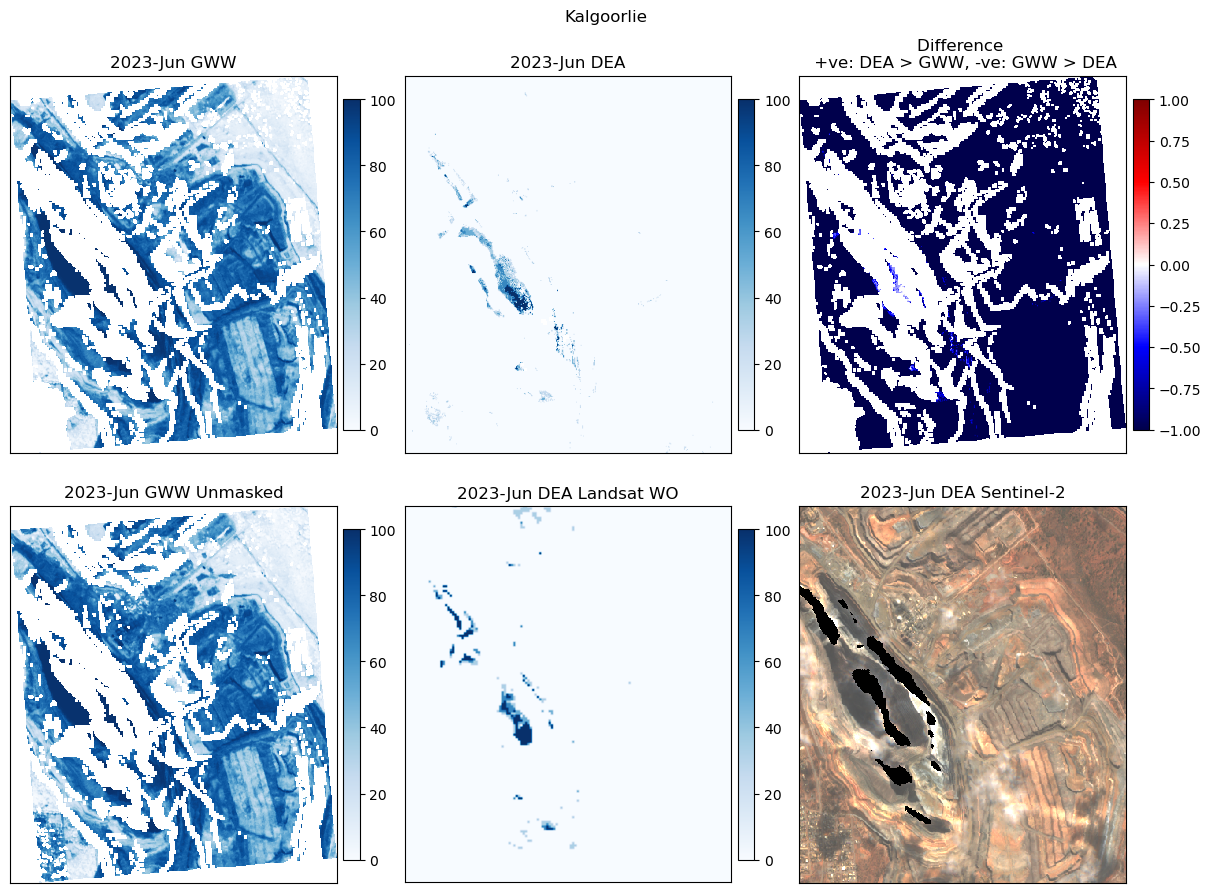

In [195]:
fig, axarr = plt.subplots(2, 3, figsize=(12, 9), squeeze=False, constrained_layout=True)

def plot_with_uniform_aspect(ax, data, cmap, vmin, vmax, title):
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')  # Set aspect ratio
    ax.set_title(title)
    ax.xaxis.set_ticks([])
    ax.yaxis.set_ticks([])
    return im

# GEE frequency
im_gee_freq = plot_with_uniform_aspect(axarr[0, 0], gee_freq, cmap=custom_cmap, vmin=0, vmax=100, title=f"{year}-{months[month - 1]['month']} GWW")
fig.colorbar(im_gee_freq, ax=axarr[0, 0], orientation='vertical', shrink=0.8, pad=0.02)

# dea frequency
im_dea_freq = plot_with_uniform_aspect(axarr[0, 1], dea_freq, cmap=custom_cmap, vmin=0, vmax=100, title=f"{year}-{months[month - 1]['month']} DEA")
fig.colorbar(im_dea_freq, ax=axarr[0, 1], orientation='vertical', shrink=0.8, pad=0.02)

# diff
im_diff = plot_with_uniform_aspect(axarr[0, 2], difference, cmap="seismic", vmin=-1, vmax=1, title="Difference \n +ve: DEA > GWW, -ve: GWW > DEA")
fig.colorbar(im_diff, ax=axarr[0, 2], orientation='vertical', shrink=0.8, pad=0.02)

# GEE freq unmasked
im_gee_no_mask = plot_with_uniform_aspect(axarr[1, 0], gee_freq_raw, cmap=custom_cmap, vmin=0, vmax=100, title=f"{year}-{months[month - 1]['month']} GWW Unmasked")
fig.colorbar(im_gee_no_mask, ax=axarr[1, 0], orientation='vertical', shrink=0.8, pad=0.02)

# Plot RGB Sentinel-2 with aspect ratio fix
rgb(
    s2.isel(time=2),
    bands=["nbart_red", "nbart_green", "nbart_blue"],
    # percentile_stretch=(0.01, 0.99),
    ax=axarr[1, 2],
    robust=True,
)
axarr[1, 2].set_title(f"{year}-{months[month - 1]['month']} DEA Sentinel-2")
axarr[1, 2].xaxis.set_ticks([])
axarr[1, 2].set_xlabel("")
axarr[1, 2].set_ylabel("")
axarr[1, 2].yaxis.set_ticks([])
axarr[1, 2].set_aspect('equal') 

# axarr[1, 2].axis('off')

# Landsat WO 
im_dea_ls_freq = plot_with_uniform_aspect(axarr[1, 1], dea_freq_ls, cmap=custom_cmap, vmin=0, vmax=100, title=f"{year}-{months[month - 1]['month']} DEA Landsat WO")
fig.colorbar(im_dea_ls_freq, ax=axarr[1, 1], orientation='vertical', shrink=0.8, pad=0.02)


fig.suptitle(aoi['location'])

plt.show()


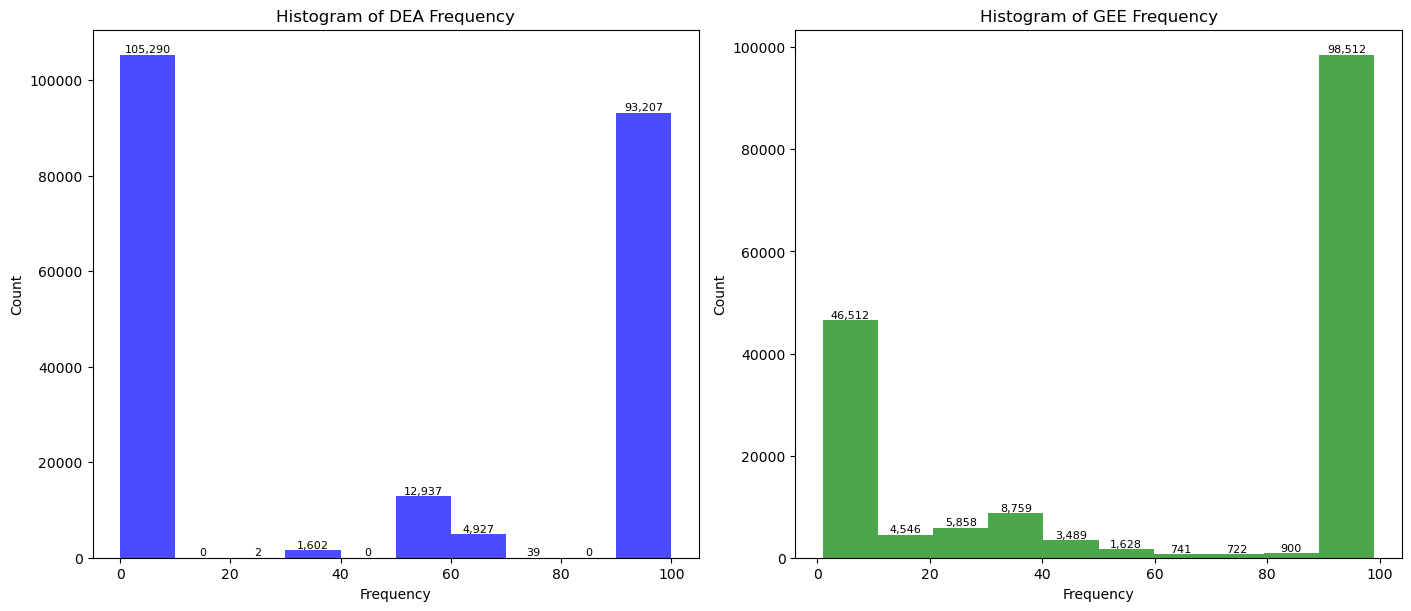

In [471]:
data_gee = gee_freq.ravel() 
data_dea = dea_freq.values.ravel()

fig, axarr = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

n_dea, bins_dea, patches_dea = axarr[0].hist(data_dea, bins=10, color='blue', alpha=0.7)
axarr[0].set_title('Histogram of DEA Frequency')
axarr[0].set_xlabel('Frequency')
axarr[0].set_ylabel('Count')

for i in range(len(patches_dea)):
    height = patches_dea[i].get_height()
    axarr[0].text(patches_dea[i].get_x() + patches_dea[i].get_width() / 2, height, f'{int(height):,}', 
                  ha='center', va='bottom', fontsize=8, color='black')

n_gee, bins_gee, patches_gee = axarr[1].hist(data_gee, bins=10, color='green', alpha=0.7)
axarr[1].set_title('Histogram of GEE Frequency')
axarr[1].set_xlabel('Frequency')
axarr[1].set_ylabel('Count')

for i in range(len(patches_gee)):
    height = patches_gee[i].get_height()
    axarr[1].text(patches_gee[i].get_x() + patches_gee[i].get_width() / 2, height, f'{int(height):,}', 
                  ha='center', va='bottom', fontsize=8, color='black')

plt.show()

In [19]:
brBg = ['#543005','#8c510a','#bf812d','#dfc27d','#f6e8c3','#f7f7f7','#d1e5f0','#92c5de','#4393c3','#2166ac','#053061']
# custom_cmap = LinearSegmentedColormap.from_list('brBg', brBg)
custom_cmap = "Blues"